In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('../data/pakwheels_data.csv')
df.head()

,name,brand,model,mileage_km,fuel_type,transmission,engine_cc,city,price_pkr
0,Toyota Surf 1997 for Sale,Toyota,1997,100000,Petrol,Automatic,2700,Gujrat,4100000
1,Suzuki Jimny 1991 for Sale,Suzuki,1991,130000,Petrol,Manual,1000,Gujrat,1100000
2,Honda City 2004 i-DSI Vario for Sale,Honda,2004,250000,Petrol,Automatic,1300,Lahore,1825000
3,Honda City 2005 i-DSI for Sale,Honda,2005,250000,Petrol,Manual,1300,Lahore,1625000
4,Toyota IST 2003 1.3 A for Sale,Toyota,2003,100000,Petrol,Automatic,1300,Karachi,1500000


In [4]:
df.shape

(26404, 9)

In [5]:
df.duplicated().sum()

1673

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.shape

(24731, 9)

# Numeric vs Categoric

## price_pkr vs brand

In [8]:
sns.set_theme(palette='pastel')

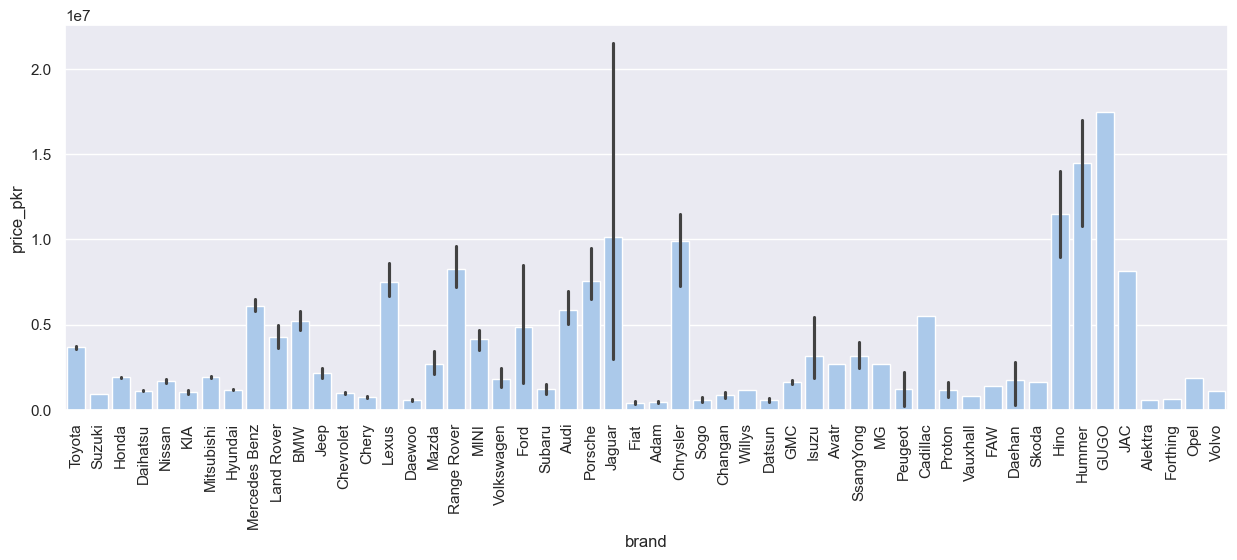

In [9]:
plt.figure(figsize=(15, 5))
sns.barplot(data=df, x='brand', y='price_pkr')
_ = plt.xticks(rotation=90)

### Only top 15 brands with most cars

In [10]:
sorted_brands = df['brand'].value_counts()

In [11]:
average_brand_prices = df.groupby('brand')['price_pkr'].mean().sort_values(ascending=False)
average_brand_prices[average_brand_prices.index == 'Suzuki']

brand
Suzuki    943408.463745
Name: price_pkr, dtype: float64

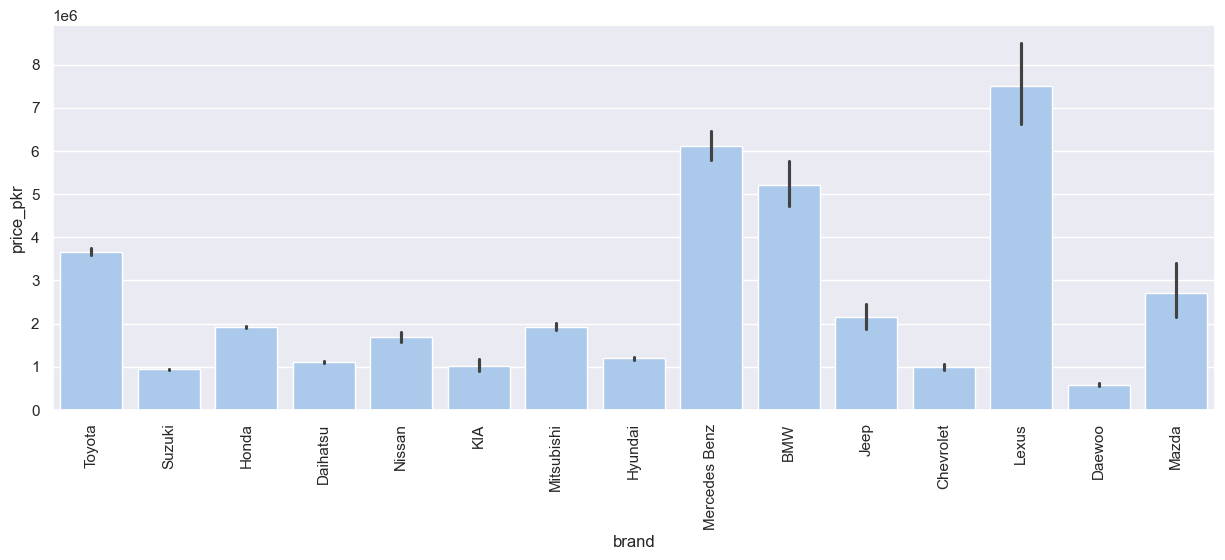

In [12]:
plt.figure(figsize=(15, 5))
sns.barplot(data=df[df['brand'].isin(sorted_brands.head(15).index)], x='brand', y='price_pkr')
_ = plt.xticks(rotation=90)

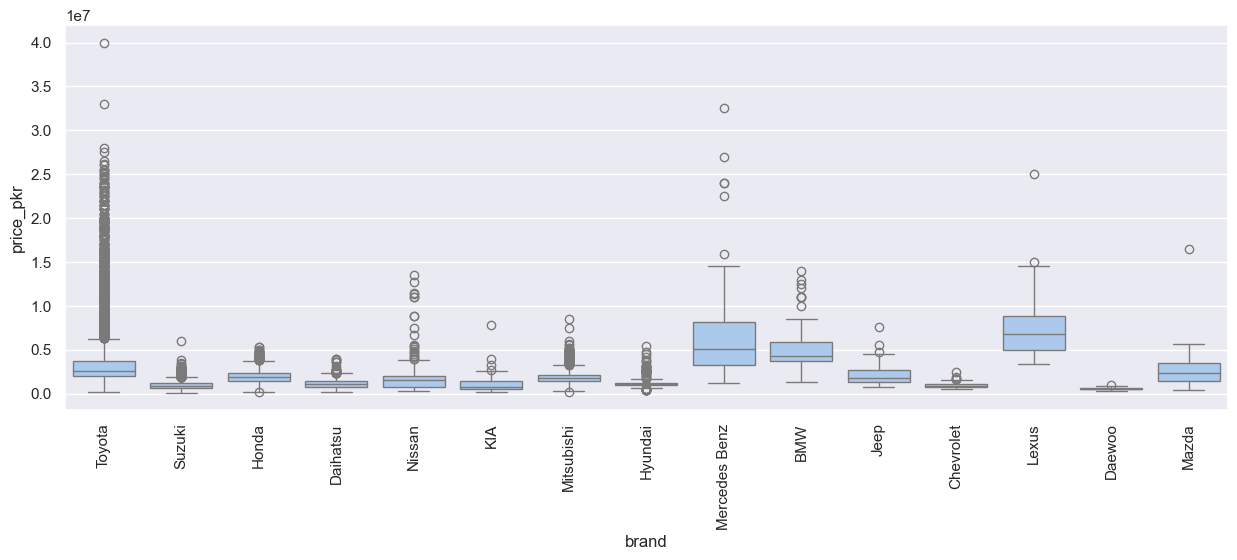

In [13]:
plt.figure(figsize=(15, 5))
sns.boxplot(data=df[df['brand'].isin(sorted_brands.head(15).index)], x='brand', y='price_pkr')
_ = plt.xticks(rotation=90)

In [14]:
df[(df['brand'] == 'Toyota') & (df['price_pkr'] == 40000000)]

,name,brand,model,mileage_km,fuel_type,transmission,engine_cc,city,price_pkr
3818,Toyota Land Cruiser 2008 ZX for Sale,Toyota,2008,60000,Petrol,Automatic,4600,Karachi,40000000


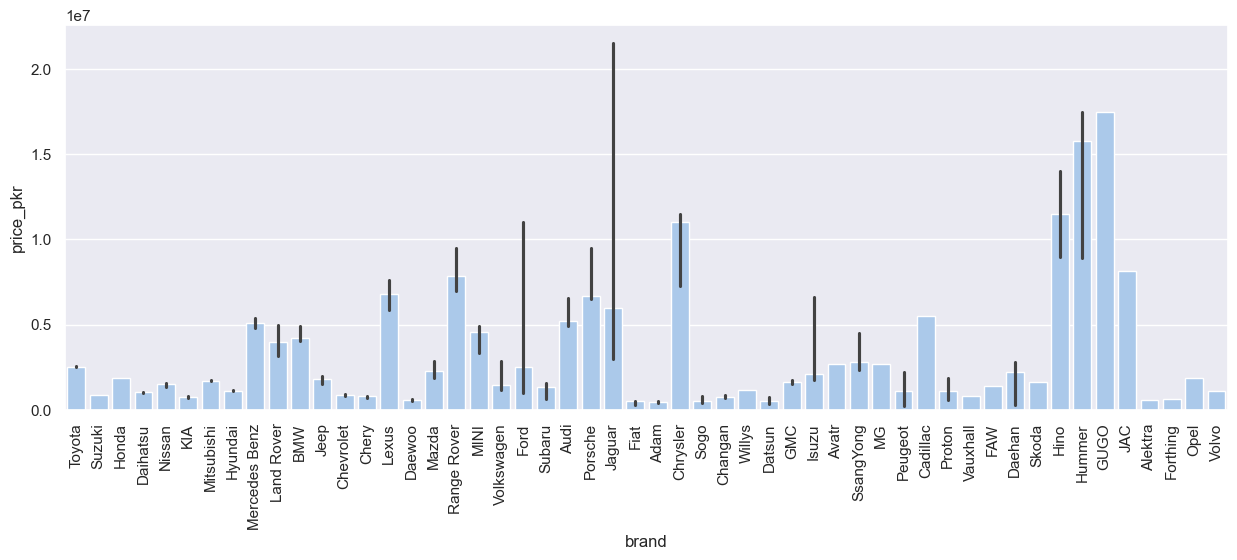

In [15]:
plt.figure(figsize=(15, 5))
sns.barplot(data=df,
            x='brand', y='price_pkr', estimator='median')
_ = plt.xticks(rotation=90)

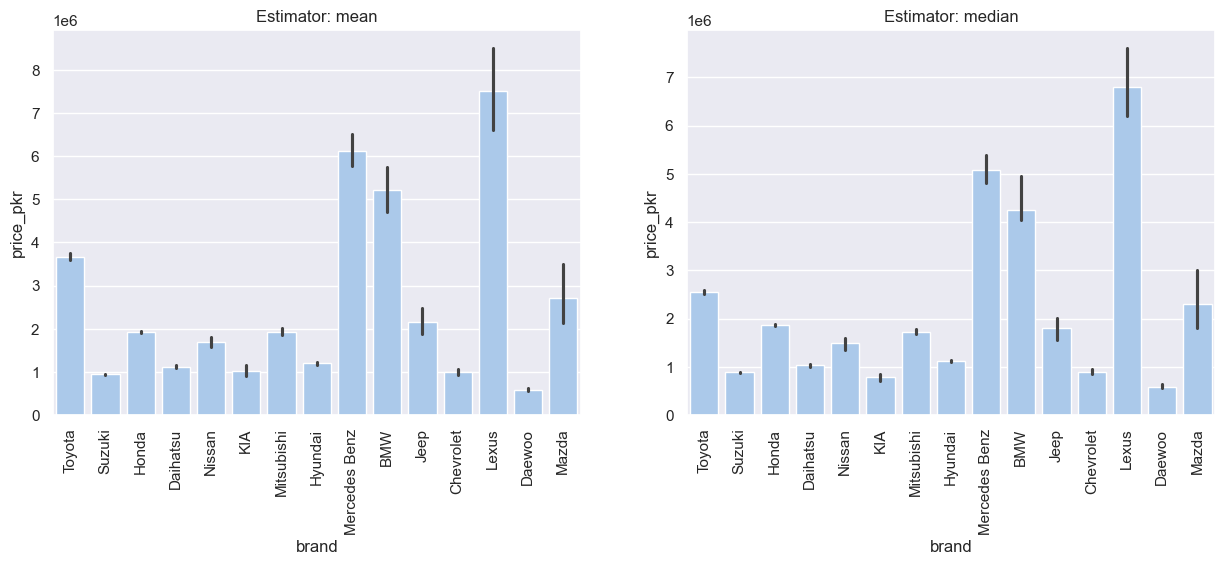

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes.flatten()
estimator = ['mean', 'median']

for i in range(2):
    sns.barplot(data=df[df['brand'].isin(sorted_brands.head(15).index)],
                x='brand', y='price_pkr', estimator=estimator[i], ax=axes[i])
    axes[i].tick_params(axis='x', labelrotation=90)
    axes[i].set_title(f'Estimator: {estimator[i]}')

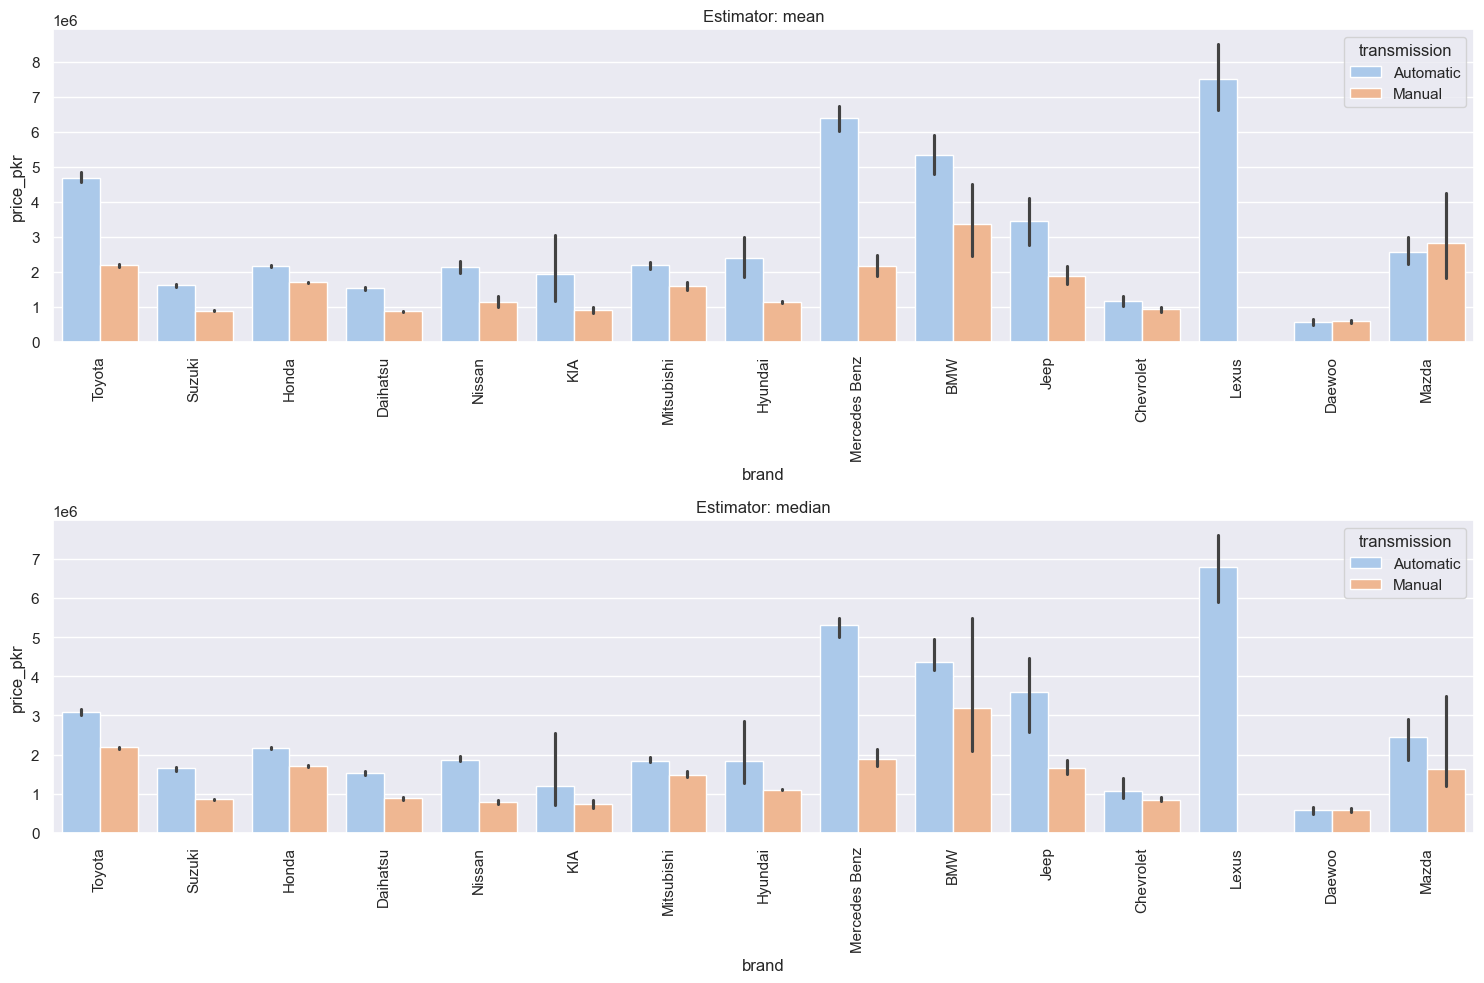

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))
axes.flatten()
estimator = ['mean', 'median']

for i in range(2):
    sns.barplot(data=df[df['brand'].isin(sorted_brands.head(15).index)],
            x='brand', y='price_pkr', estimator=estimator[i], hue='transmission', ax=axes[i])
    axes[i].tick_params(axis='x', labelrotation=90)
    axes[i].set_title(f'Estimator: {estimator[i]}')
    
plt.tight_layout()

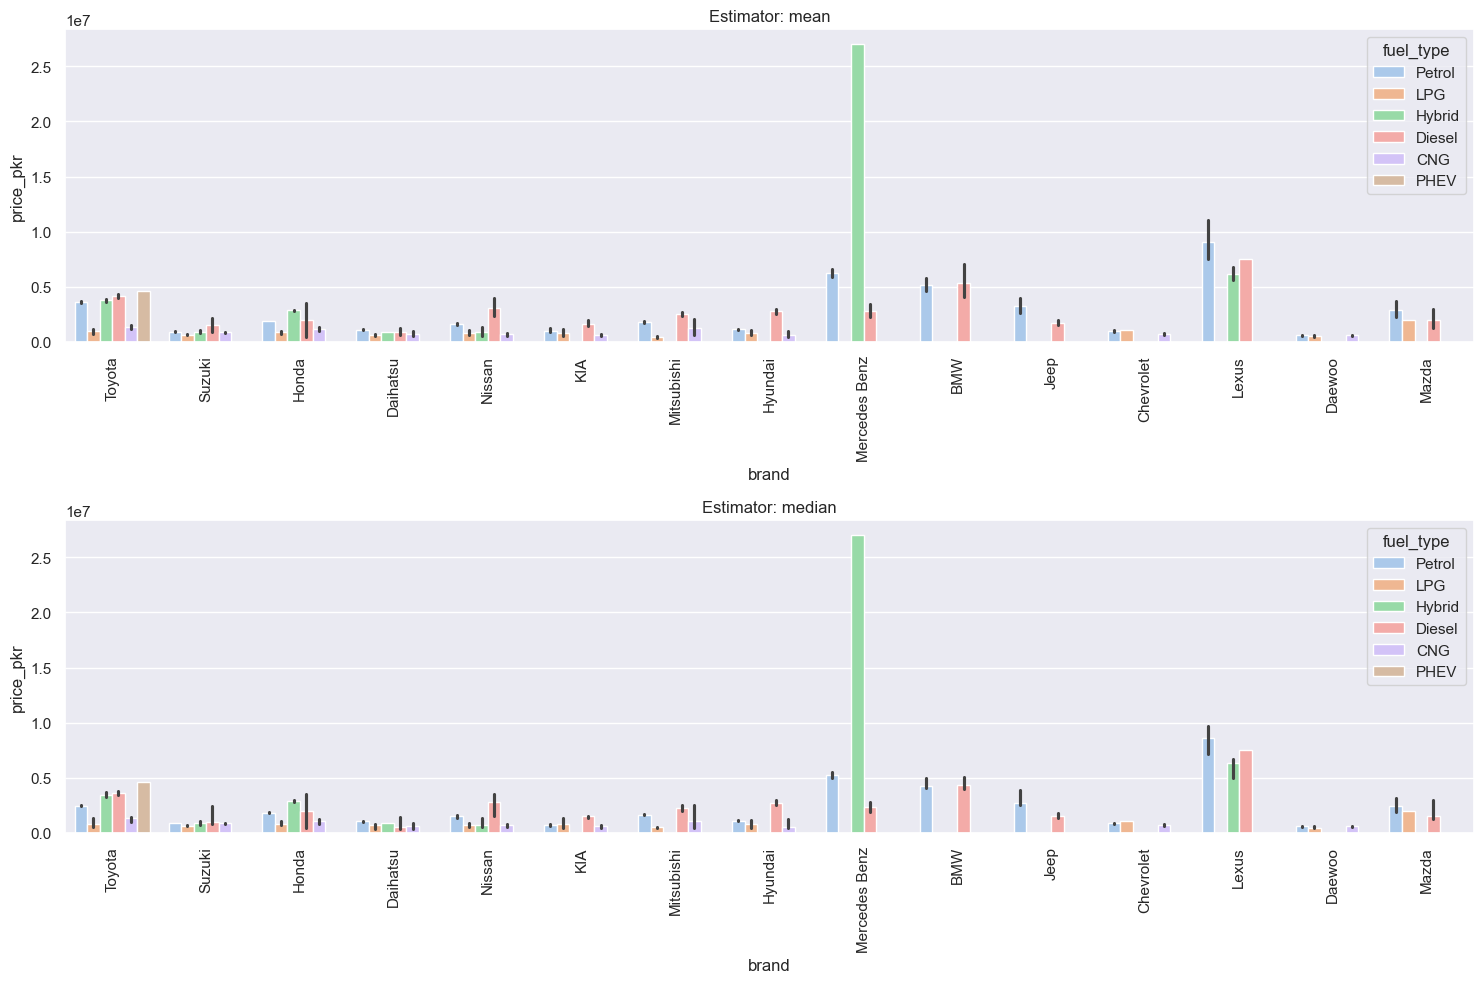

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))
axes.flatten()
estimator = ['mean', 'median']

for i in range(2):
    sns.barplot(data=df[df['brand'].isin(sorted_brands.head(15).index)],
            x='brand', y='price_pkr', estimator=estimator[i], hue='fuel_type', ax=axes[i])
    axes[i].tick_params(axis='x', labelrotation=90)
    axes[i].set_title(f'Estimator: {estimator[i]}')
    
plt.tight_layout()

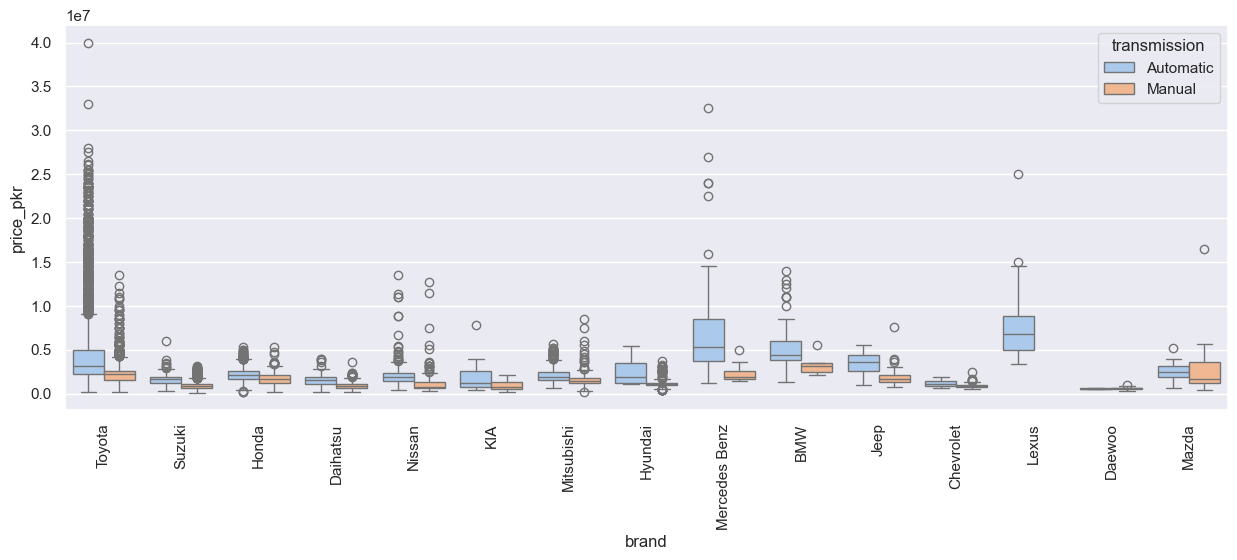

In [19]:
plt.figure(figsize=(15, 5))
sns.boxplot(data=df[df['brand'].isin(sorted_brands.head(15).index)],
            x='brand', y='price_pkr', hue='transmission')
_ = plt.xticks(rotation=90)

In [20]:
df[(df['brand'] == 'Toyota') & (df['price_pkr']>1e7)]

,name,brand,model,mileage_km,fuel_type,transmission,engine_cc,city,price_pkr
8,Toyota Prado 2011 TX 2.7 for Sale,Toyota,2011,64373,Petrol,Automatic,2700,Karachi,13760000
161,Toyota Surf 2004 SSR-G 3.4 for Sale,Toyota,2004,117000,Petrol,Automatic,3400,Peshawar,10500000
221,Toyota Land Cruiser 2008 AX G Selection for Sale,Toyota,2008,185000,Petrol,Automatic,4600,Gujrat,19200000
225,Toyota Land Cruiser 2009 AX G Selection for Sale,Toyota,2009,122000,Petrol,Automatic,4600,Hyderabad,19500000
373,Toyota Prado 2011 TX 2.7 for Sale,Toyota,2011,86000,Petrol,Automatic,2700,Karachi,11325000
...,...,...,...,...,...,...,...,...,...
21644,Toyota Land Cruiser 2011 AX for Sale,Toyota,2011,102000,Petrol,Automatic,4600,Jhelum,22500000
21645,Toyota Land Cruiser 2008 AX G Selection for Sale,Toyota,2008,160000,Petrol,Automatic,4608,Sargodha,19000000
21650,Toyota Prado 2011 TX L Package 2.7 for Sale,Toyota,2011,119000,Petrol,Automatic,2700,Faisalabad,16300000
21651,Toyota Land Cruiser 2007 AX for Sale,Toyota,2007,175000,Petrol,Automatic,4600,Mandi bahauddin,18500000


## price_pkr vs model

In [21]:
len(df['city'].unique())

279

## top cities

In [22]:
sorted_citites = df['city'].value_counts()

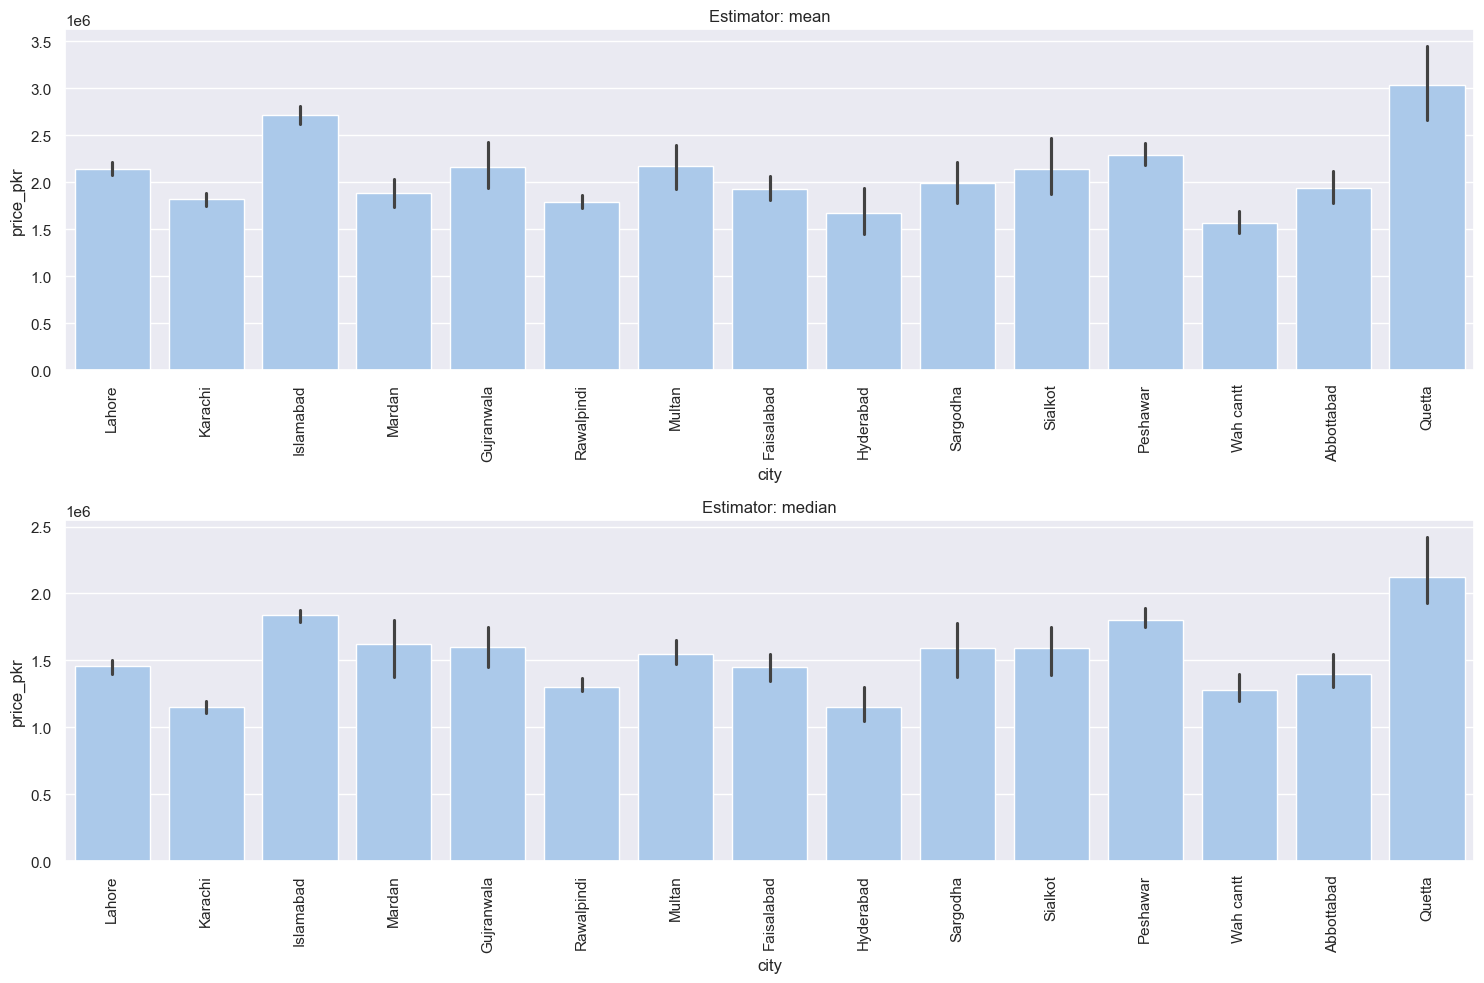

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))
axes.flatten()
estimator = ['mean', 'median']

for i in range(2):
    sns.barplot(data=df[df['city'].isin(sorted_citites.head(15).index)],
            x='city', y='price_pkr', estimator=estimator[i], ax=axes[i])
    axes[i].tick_params(axis='x', labelrotation=90)
    axes[i].set_title(f'Estimator: {estimator[i]}')
    
plt.tight_layout()

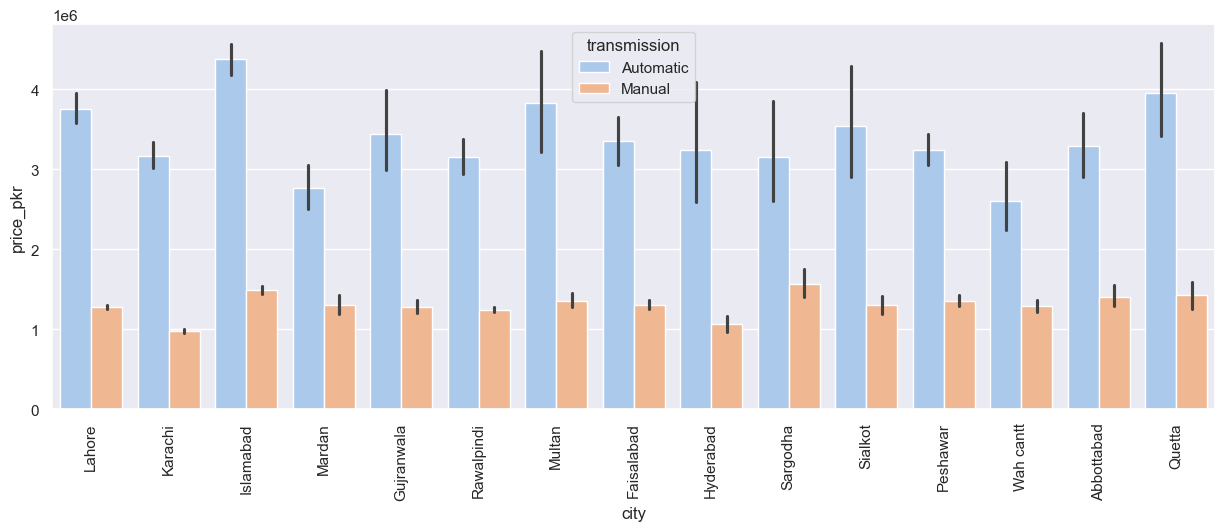

In [24]:
plt.figure(figsize=(15, 5))
sns.barplot(data=df[df['city'].isin(sorted_citites.head(15).index)],
            x='city', y='price_pkr', hue='transmission')
_ = plt.xticks(rotation=90)

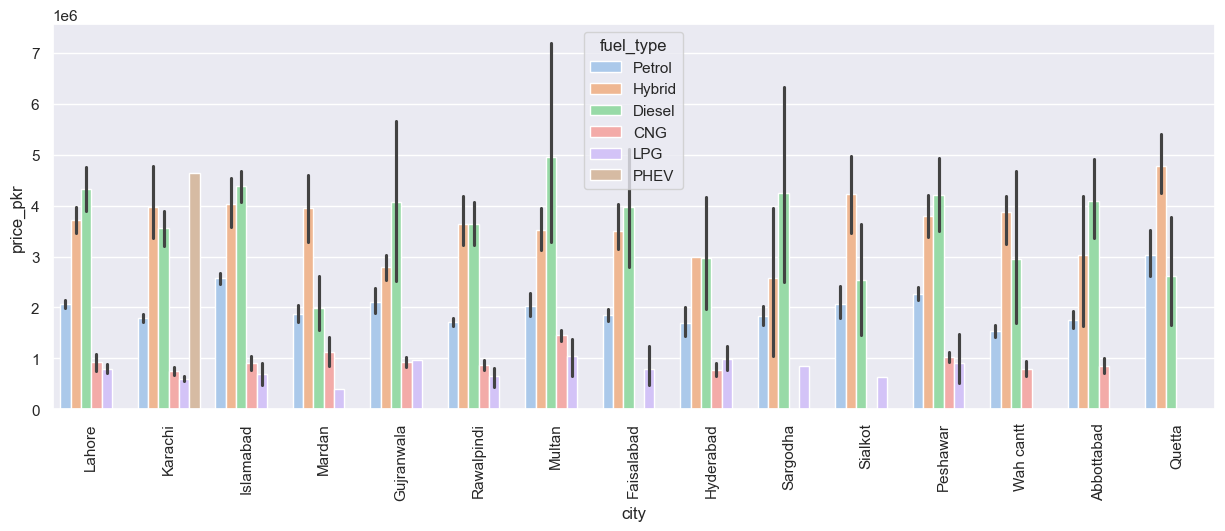

In [25]:
plt.figure(figsize=(15, 5))
sns.barplot(data=df[df['city'].isin(sorted_citites.head(15).index)],
            x='city', y='price_pkr', hue='fuel_type')
_ = plt.xticks(rotation=90)

## fuel_type vs price_pkr

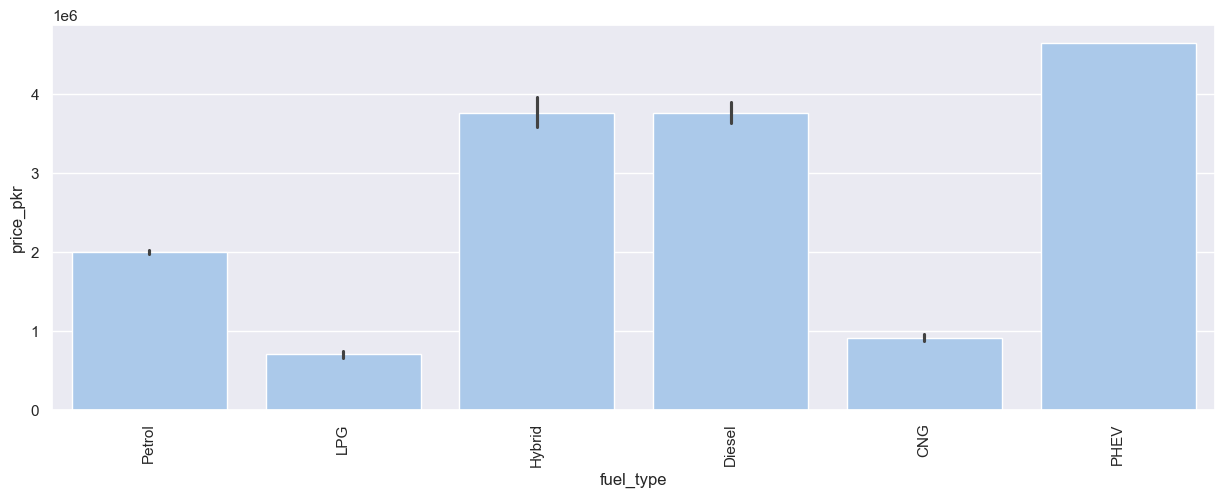

In [26]:
plt.figure(figsize=(15, 5))
sns.barplot(data=df, x='fuel_type', y='price_pkr')
_ = plt.xticks(rotation=90)

## transmission vs price_pkr

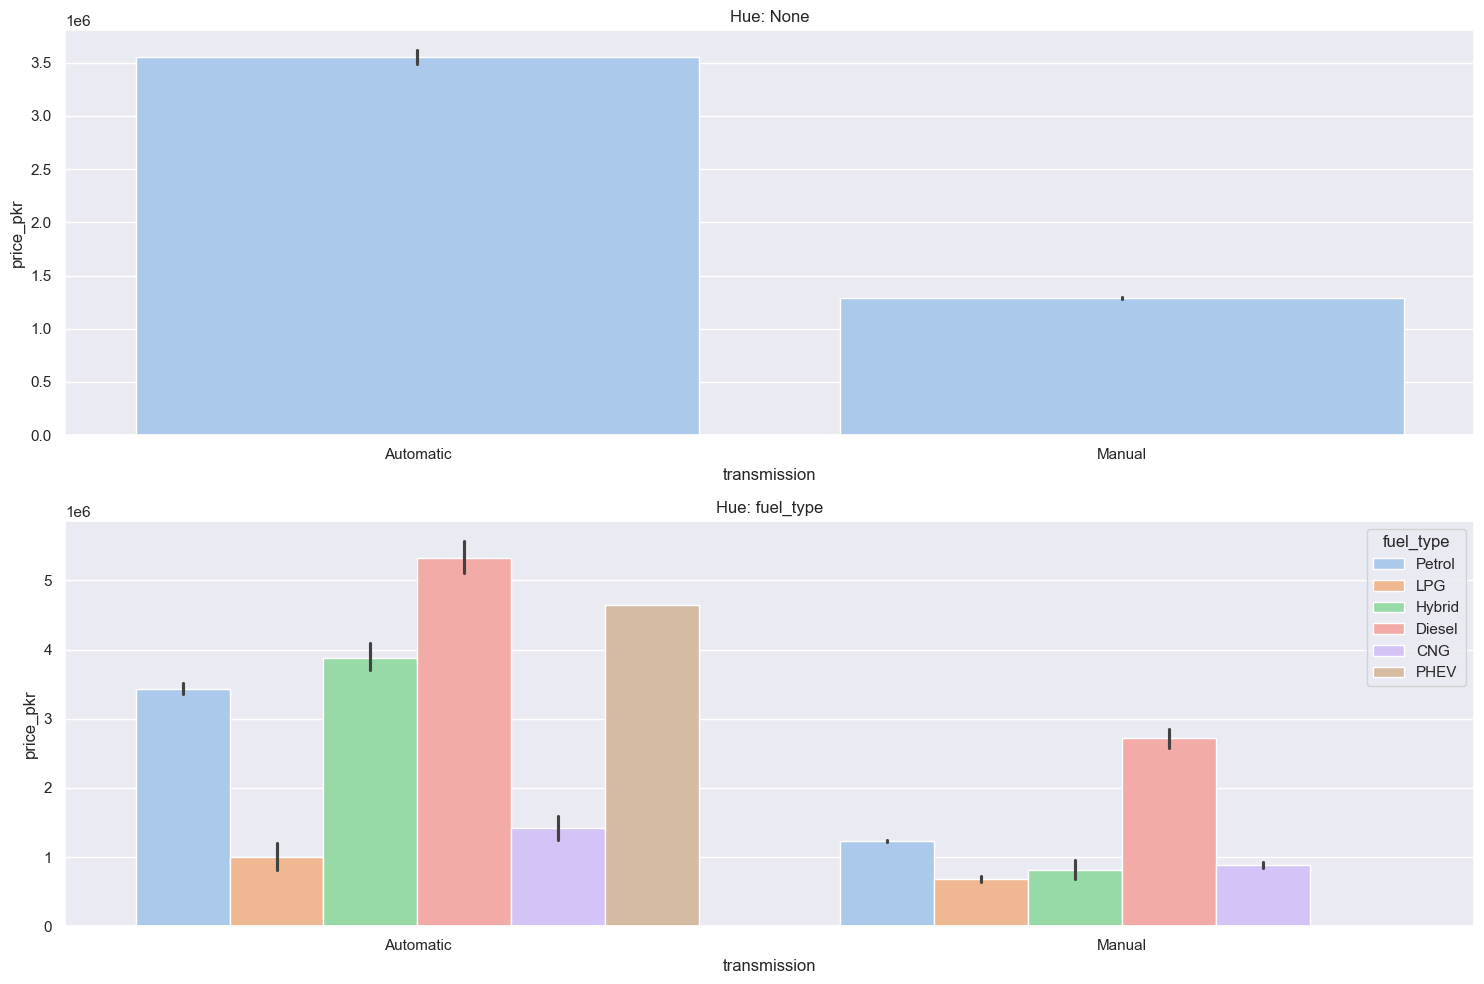

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))
axes.flatten()
hue = [None, 'fuel_type']

for i in range(2):
    sns.barplot(data=df, x='transmission', y='price_pkr', hue=hue[i], ax=axes[i])
    axes[i].set_title(f'Hue: {hue[i]}')
    
plt.tight_layout()

## engine_cc vs price_pkr

In [28]:
len(df['engine_cc'].unique())

118

In [29]:
common_engines = df['engine_cc'].value_counts()

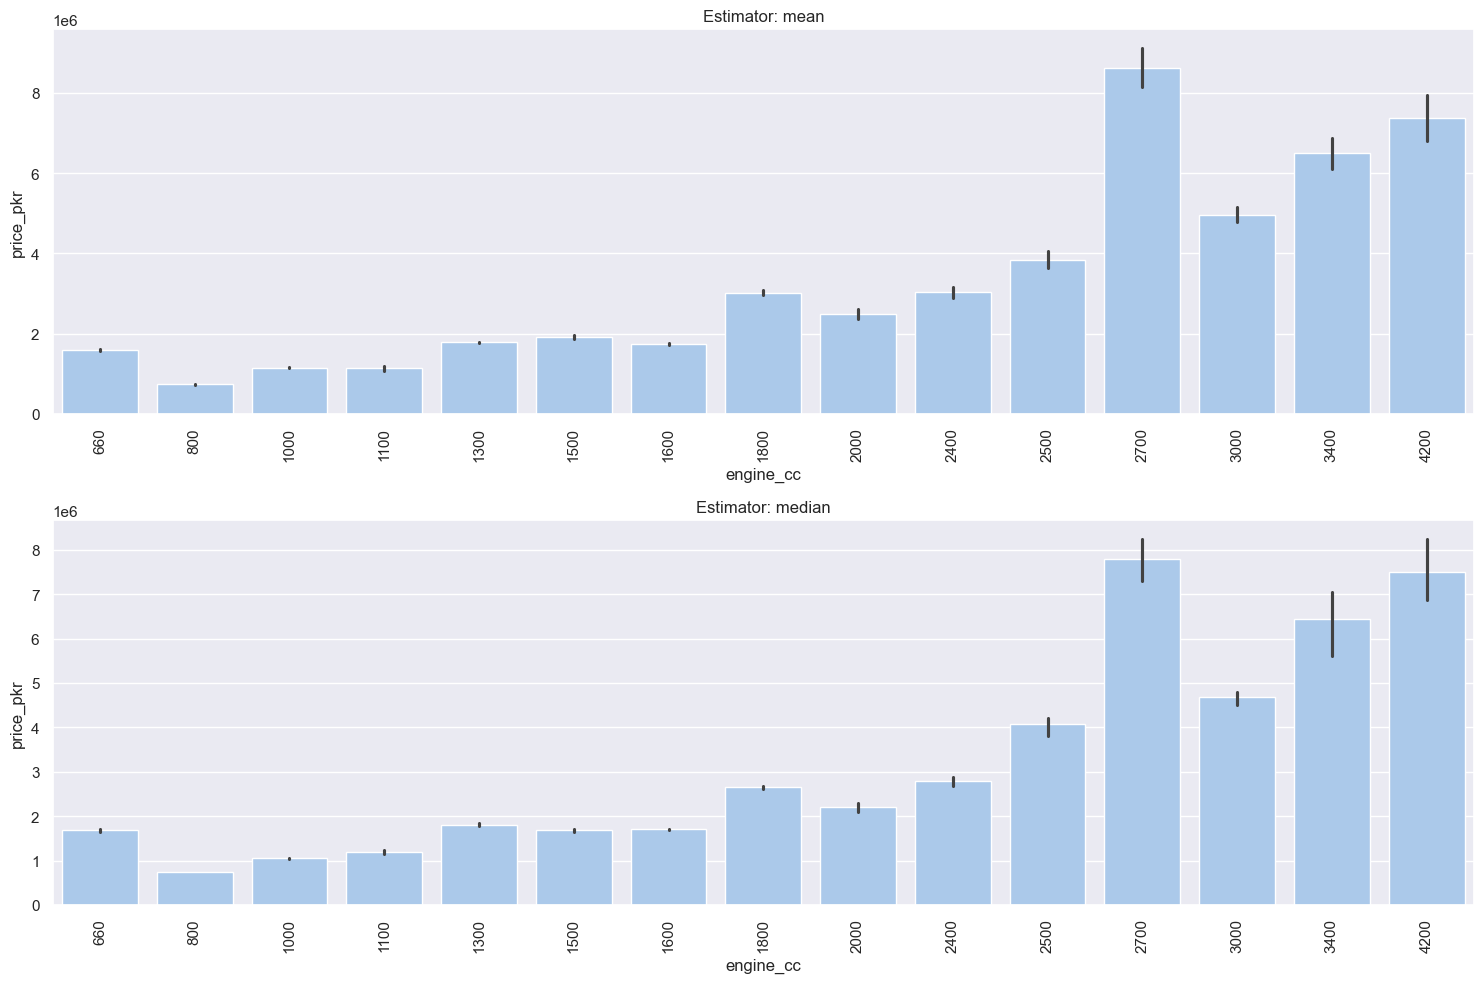

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))
axes.flatten()
estimator = ['mean', 'median']

for i in range(2):
    sns.barplot(data=df[df['engine_cc'].isin(common_engines.head(15).index)], x='engine_cc', y='price_pkr',
                estimator=estimator[i], ax=axes[i])
    axes[i].tick_params(axis='x', labelrotation=90)
    axes[i].set_title(f'Estimator: {estimator[i]}')
    
plt.tight_layout()

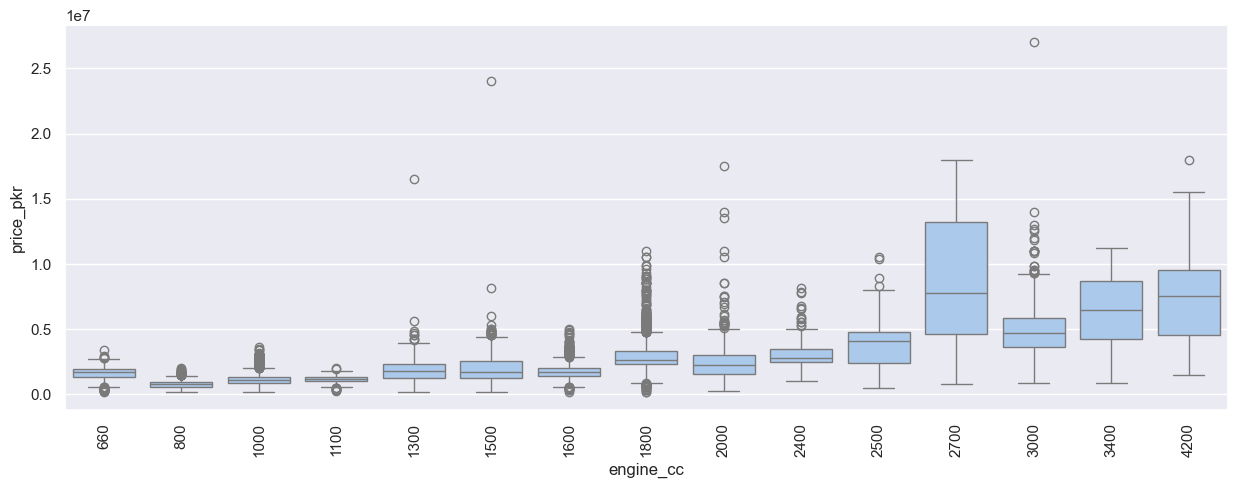

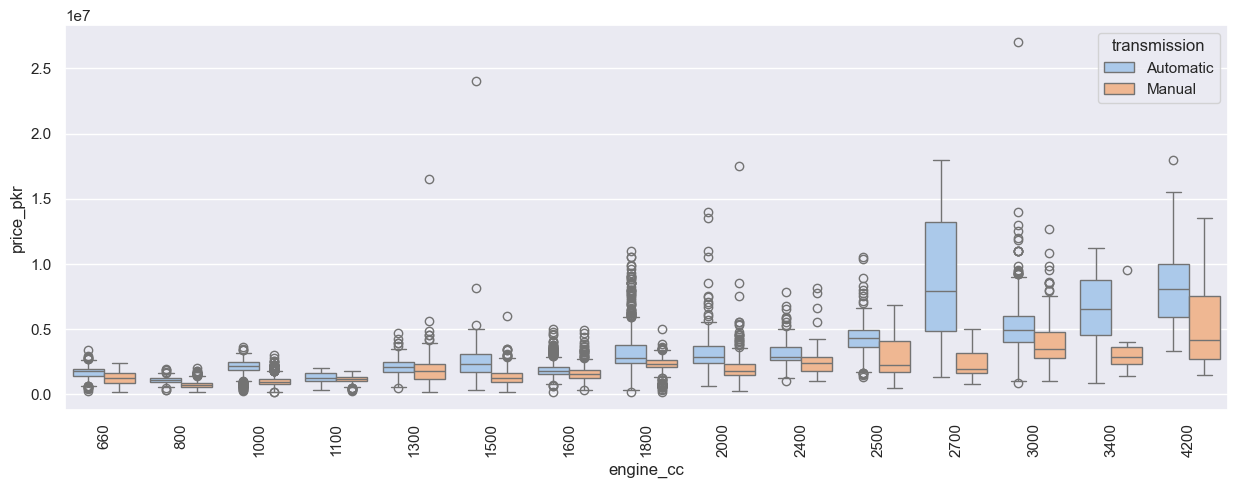

In [31]:
plt.figure(figsize=(15, 5))
sns.boxplot(data=df[df['engine_cc'].isin(common_engines.head(15).index)],
            x='engine_cc', y='price_pkr')
_ = plt.xticks(rotation=90)

plt.figure(figsize=(15, 5))
sns.boxplot(data=df[df['engine_cc'].isin(common_engines.head(15).index)],
            x='engine_cc', y='price_pkr', hue='transmission')
_ = plt.xticks(rotation=90)

In [32]:
engines = [1300, 1500, 3000, 2000]
prices = [1.5e7, 2e7, 2.5e7, 1e7]
result = pd.DataFrame()

for i in range(len(engines)):
    result = pd.concat([df[(df['engine_cc'] == engines[i]) & (df['price_pkr'] > prices[i])], result],
                       ignore_index=True)
    
result


,name,brand,model,mileage_km,fuel_type,transmission,engine_cc,city,price_pkr
0,GUGO Tourer 1940 for Sale,GUGO,1940,1000,Diesel,Manual,2000,Sargodha,17500000
1,Mercedes Benz E Class Coupe 2010 E 250 for Sale,Mercedes Benz,2010,75000,Petrol,Automatic,2000,Karachi,10500000
2,Mercedes Benz E Class Coupe 2011 E 200 for Sale,Mercedes Benz,2011,57000,Petrol,Automatic,2000,Karachi,13500000
3,BMW 5 Series 6th (F10) Generation 2011 520d fo...,BMW,2011,42000,Diesel,Automatic,2000,Islamabad,11000000
4,Mercedes Benz E Class Cabriolet 2010 E 250 fo...,Mercedes Benz,2010,48000,Petrol,Automatic,2000,Lahore,14000000
5,Mercedes Benz S Class 2008 for Sale,Mercedes Benz,2008,54000,Hybrid,Automatic,3000,Karachi,27000000
6,Mercedes Benz A Class 2010 for Sale,Mercedes Benz,2010,25000,Petrol,Automatic,1500,Karachi,24000000
7,Mazda Rx7 1997 for Sale,Mazda,1997,2000,Petrol,Manual,1300,Islamabad,16500000


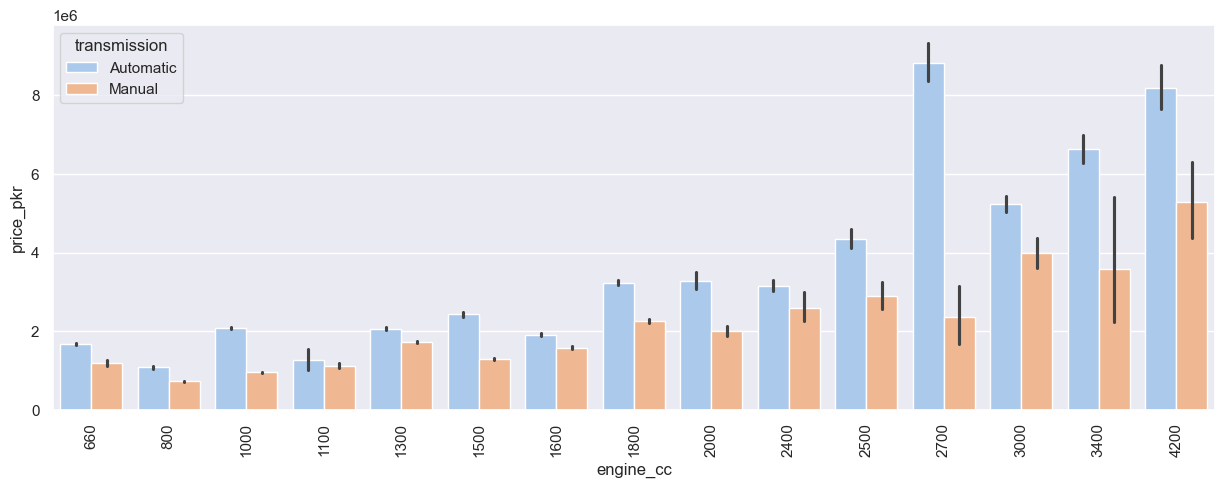

In [33]:
plt.figure(figsize=(15, 5))
sns.barplot(data=df[df['engine_cc'].isin(common_engines.head(15).index)], x='engine_cc', y='price_pkr',
                hue="transmission")
_ = plt.xticks(rotation=90)

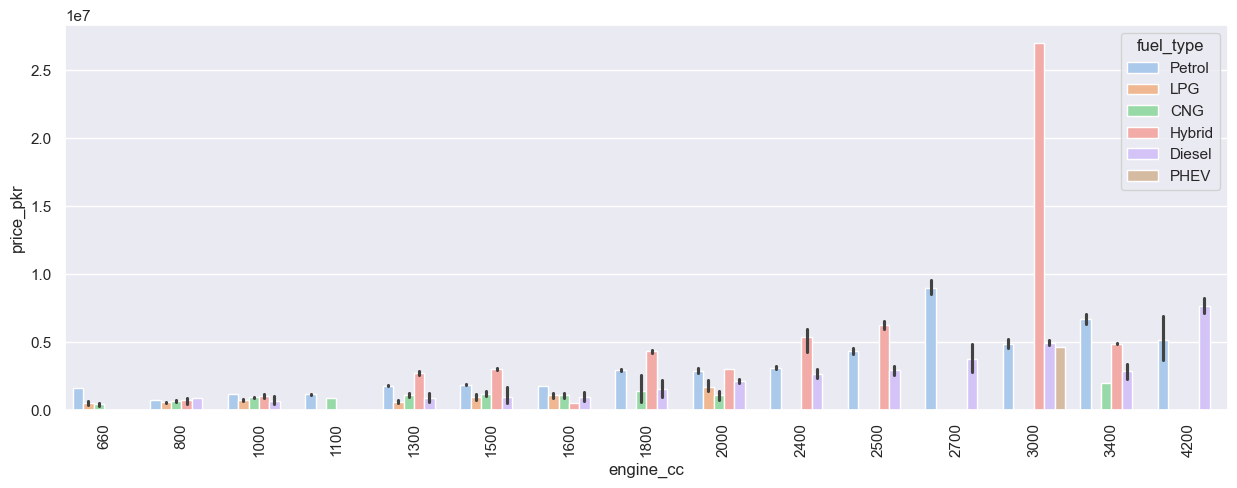

In [34]:
plt.figure(figsize=(15, 5))
sns.barplot(data=df[df['engine_cc'].isin(common_engines.head(15).index)], x='engine_cc', y='price_pkr',
                hue="fuel_type")
_ = plt.xticks(rotation=90)

# Numeric vs Numeric

In [35]:
df.head()

,name,brand,model,mileage_km,fuel_type,transmission,engine_cc,city,price_pkr
0,Toyota Surf 1997 for Sale,Toyota,1997,100000,Petrol,Automatic,2700,Gujrat,4100000
1,Suzuki Jimny 1991 for Sale,Suzuki,1991,130000,Petrol,Manual,1000,Gujrat,1100000
2,Honda City 2004 i-DSI Vario for Sale,Honda,2004,250000,Petrol,Automatic,1300,Lahore,1825000
3,Honda City 2005 i-DSI for Sale,Honda,2005,250000,Petrol,Manual,1300,Lahore,1625000
4,Toyota IST 2003 1.3 A for Sale,Toyota,2003,100000,Petrol,Automatic,1300,Karachi,1500000


## model vs price_pkr

<Axes: xlabel='model', ylabel='price_pkr'>

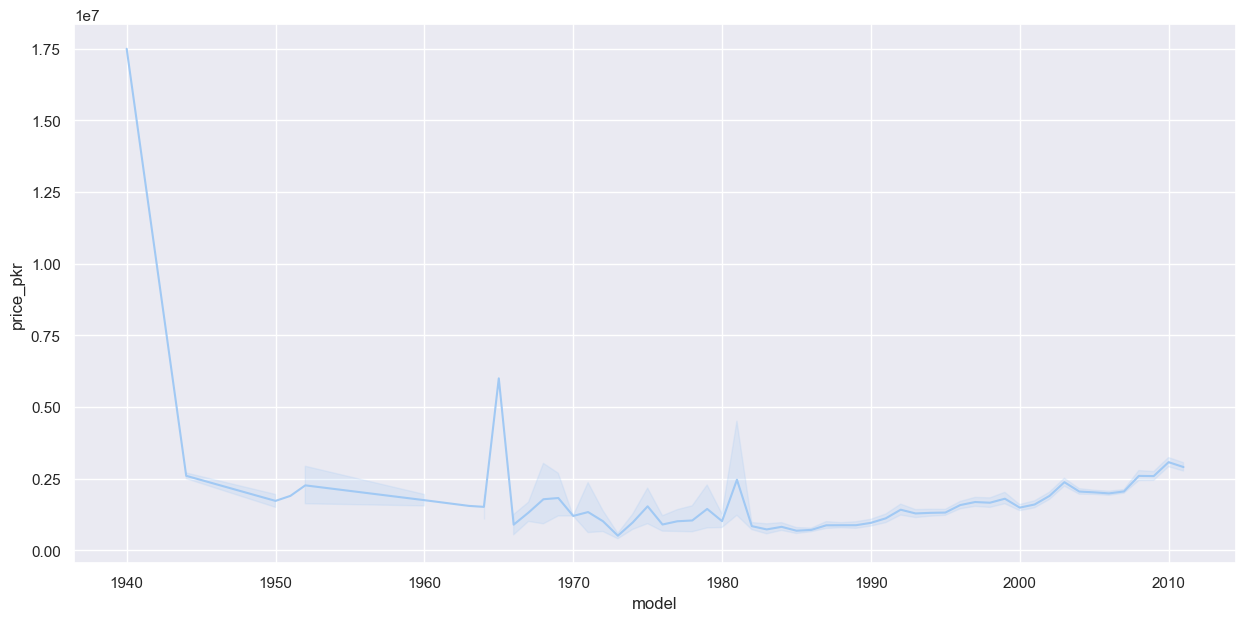

In [36]:
plt.figure(figsize=(15, 7))
sns.lineplot(data=df, x='model', y='price_pkr')

<Axes: xlabel='model', ylabel='price_pkr'>

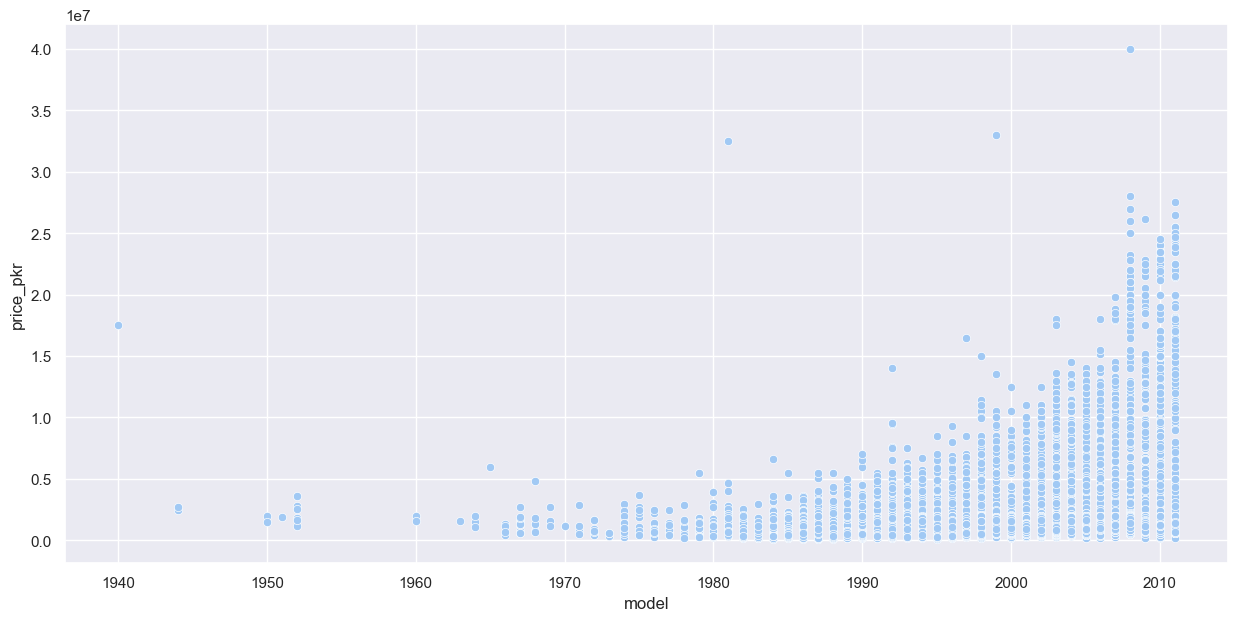

In [37]:
plt.figure(figsize=(15, 7))
sns.scatterplot(data=df, x='model', y='price_pkr')

<Axes: xlabel='mileage_km', ylabel='price_pkr'>

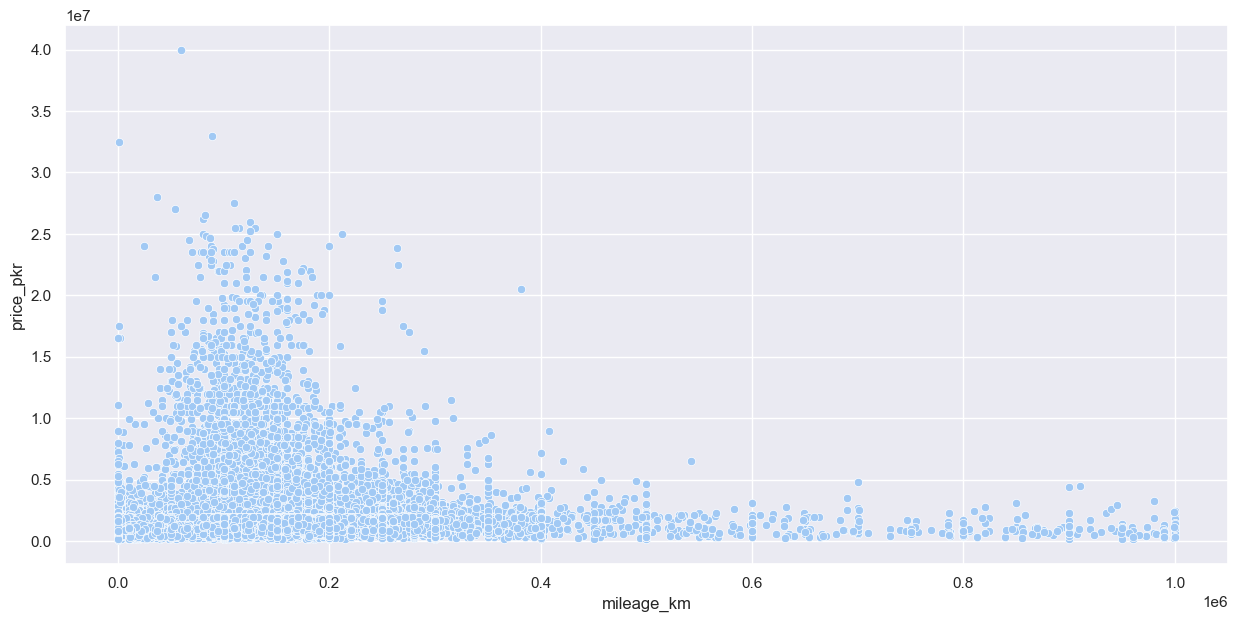

In [38]:
plt.figure(figsize=(15, 7))
sns.scatterplot(data=df, x='mileage_km', y='price_pkr')

## Categoric vs Categoric

In [39]:
df.head()

,name,brand,model,mileage_km,fuel_type,transmission,engine_cc,city,price_pkr
0,Toyota Surf 1997 for Sale,Toyota,1997,100000,Petrol,Automatic,2700,Gujrat,4100000
1,Suzuki Jimny 1991 for Sale,Suzuki,1991,130000,Petrol,Manual,1000,Gujrat,1100000
2,Honda City 2004 i-DSI Vario for Sale,Honda,2004,250000,Petrol,Automatic,1300,Lahore,1825000
3,Honda City 2005 i-DSI for Sale,Honda,2005,250000,Petrol,Manual,1300,Lahore,1625000
4,Toyota IST 2003 1.3 A for Sale,Toyota,2003,100000,Petrol,Automatic,1300,Karachi,1500000


## brand vs city

<Axes: xlabel='city', ylabel='brand'>

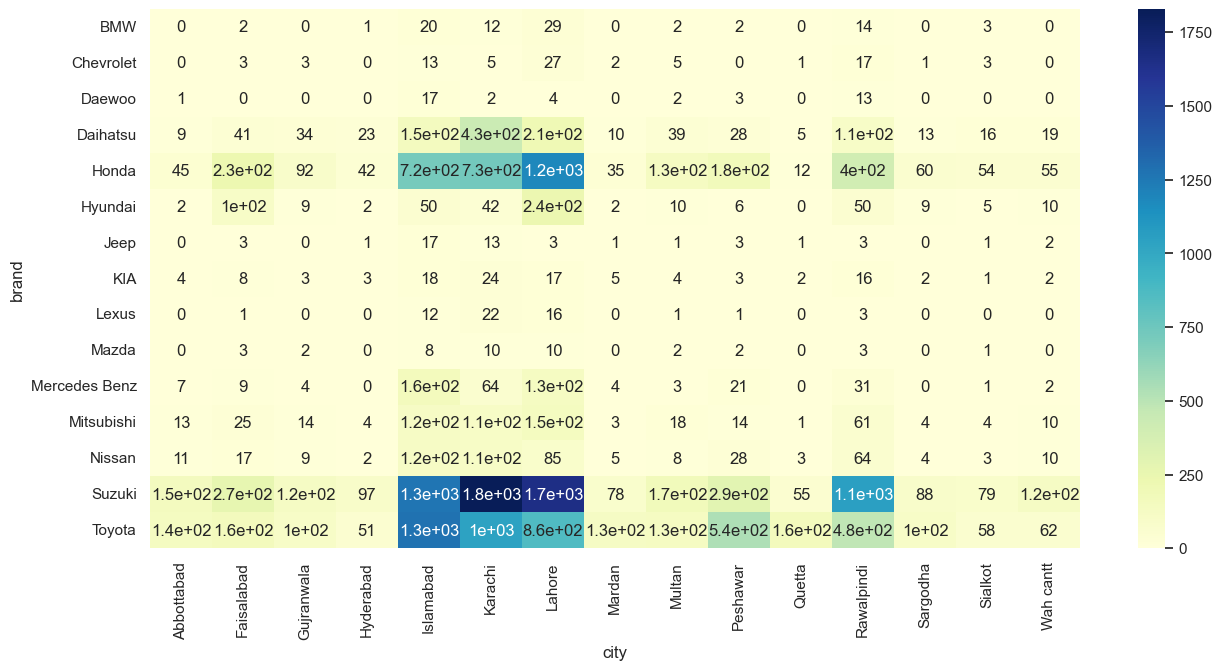

In [48]:
filtered_df = df[
    df['brand'].isin(sorted_brands.head(15).index) & 
    df['city'].isin(sorted_citites.head(15).index)
    ]

plt.figure(figsize=(15, 7))
sns.heatmap(pd.crosstab(filtered_df['brand'], filtered_df['city']), cmap='YlGnBu', annot=True)

<Axes: xlabel='transmission', ylabel='brand'>

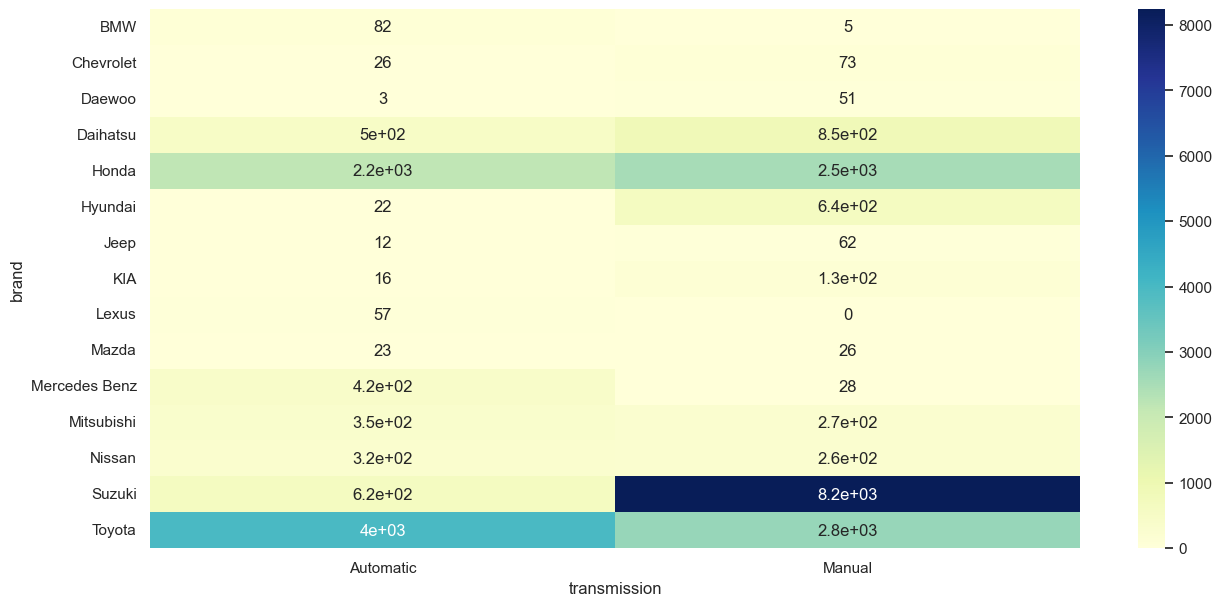

In [50]:
filtered_df = df[df['brand'].isin(sorted_brands.head(15).index)]

plt.figure(figsize=(15, 7))
sns.heatmap(pd.crosstab(filtered_df['brand'], filtered_df['transmission']), cmap='YlGnBu', annot=True)

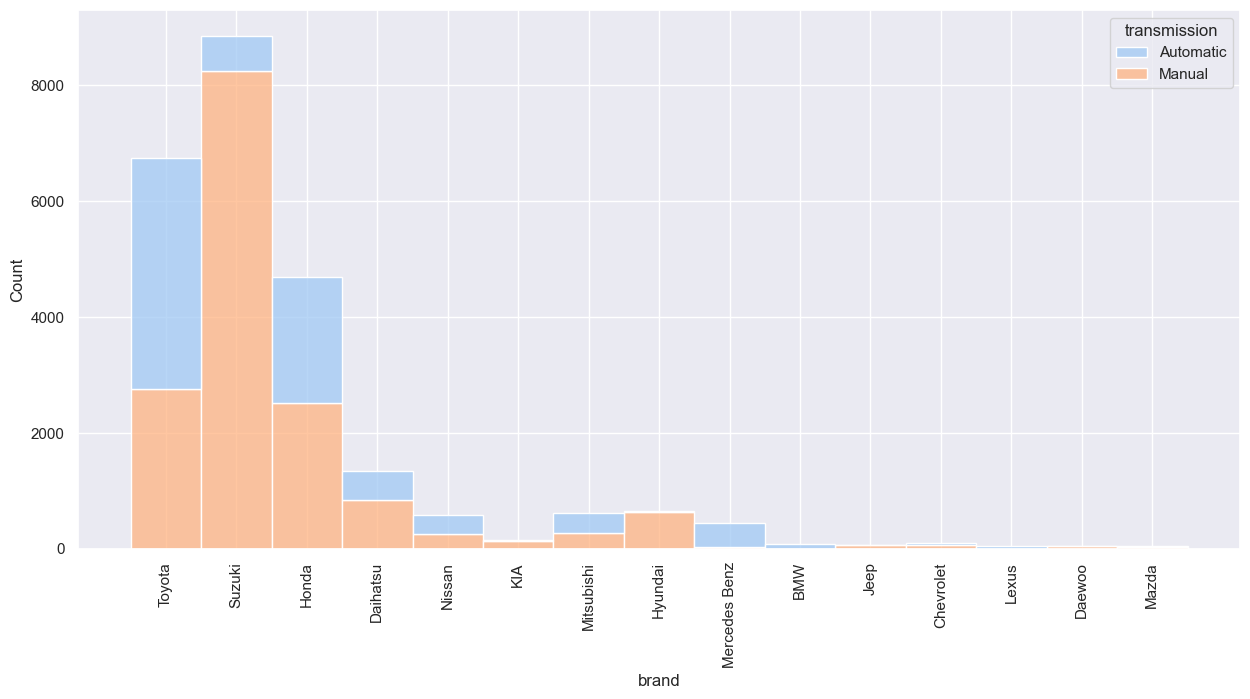

In [60]:
plt.figure(figsize=(15, 7))
sns.histplot(
    data=df[df['brand'].isin(sorted_brands.head(15).index)], 
    x='brand', 
    hue='transmission', 
    multiple='stack'
)
_ = plt.xticks(rotation=90)

<Axes: xlabel='fuel_type', ylabel='brand'>

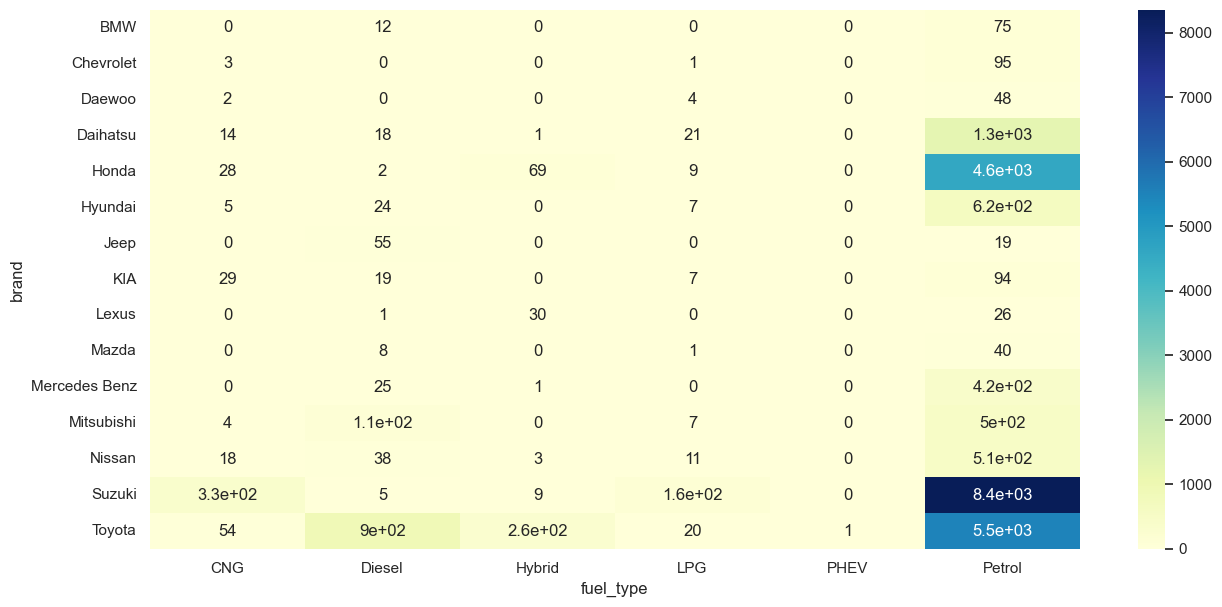

In [51]:
filtered_df = df[df['brand'].isin(sorted_brands.head(15).index)]

plt.figure(figsize=(15, 7))
sns.heatmap(pd.crosstab(filtered_df['brand'], filtered_df['fuel_type']), cmap='YlGnBu', annot=True)

# Multivariate Analysis

C:\Users\hamza\AppData\Local\Temp\ipykernel_15340\4141180147.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.relplot(


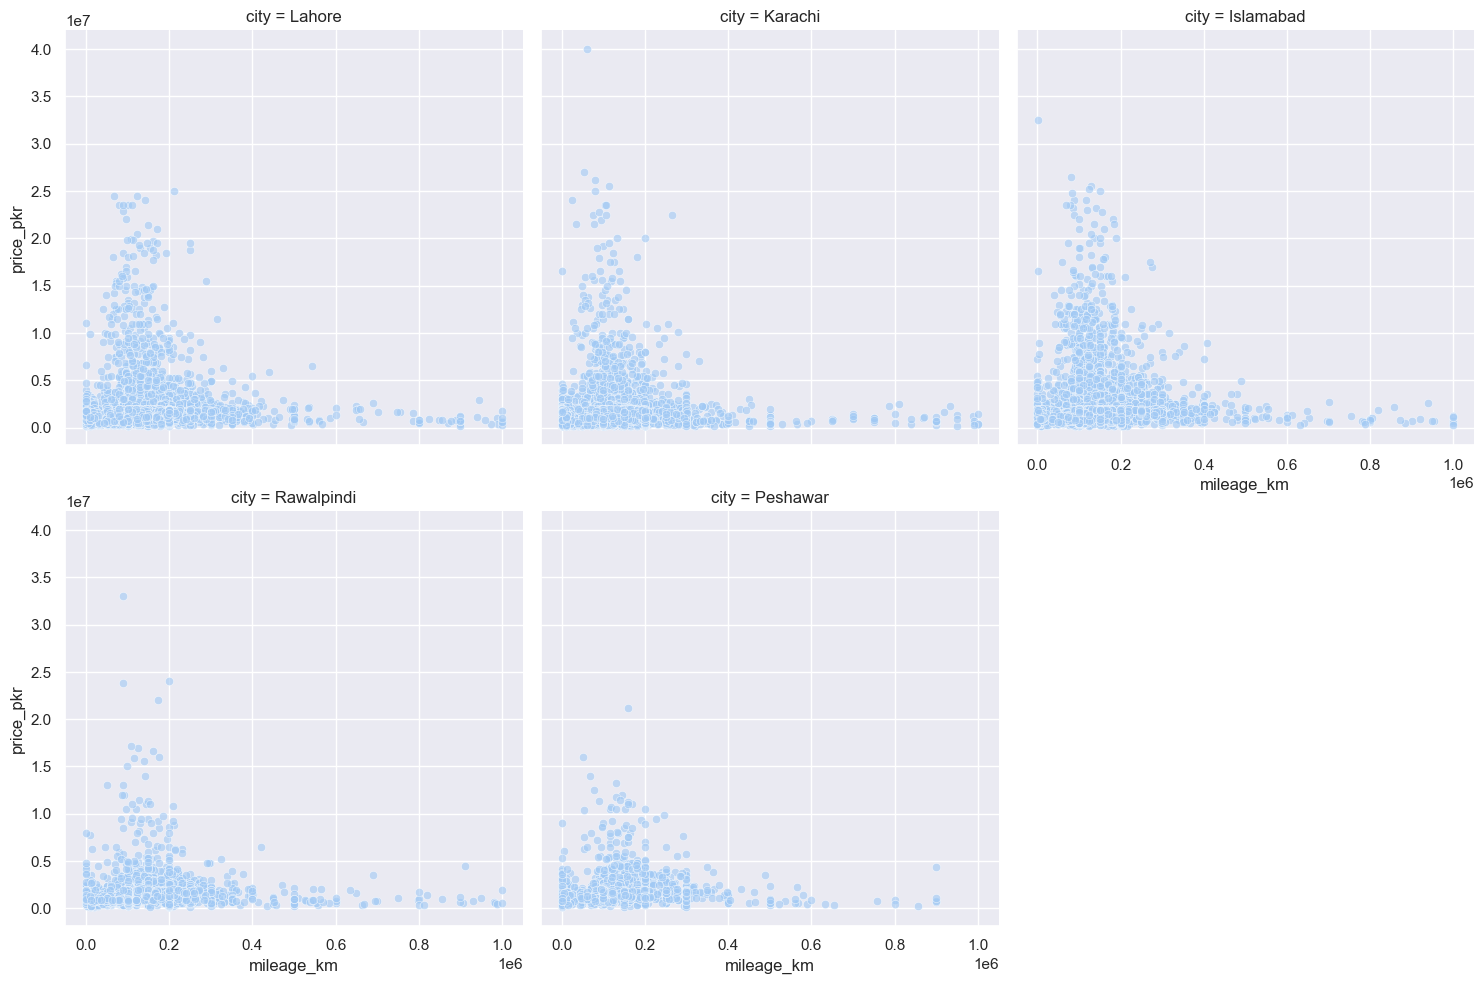

In [68]:
sns.relplot(
    data=df[df['city'].isin(sorted_citites.head(5).index)],
    x='mileage_km',
    y='price_pkr',
    col='city',       # Creates a subplot for each city
    col_wrap=3,       # Wraps the layout into 3 columns maximum
    kind='scatter',
    alpha=0.6,
    palette='viridis'
)

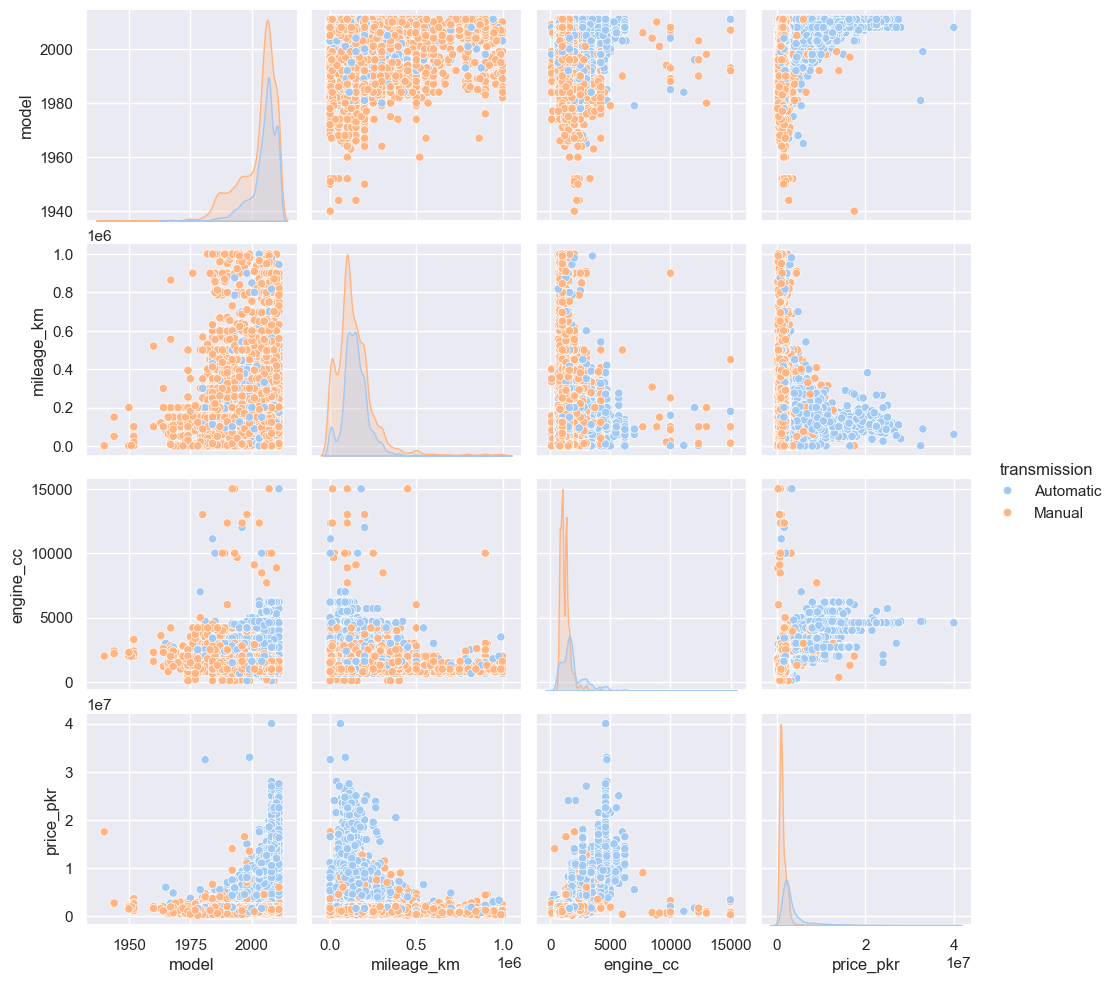

In [ ]:
sns.pairplot(df, hue='transmission')

<Axes: >

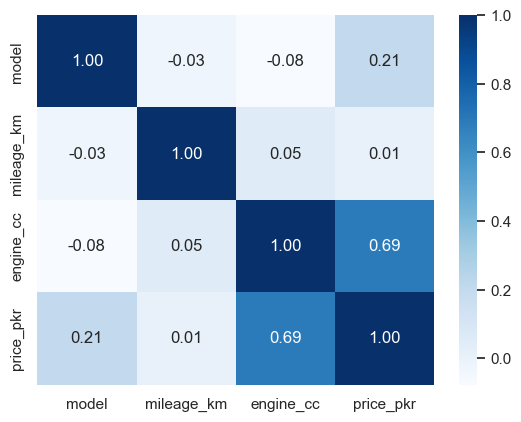

In [41]:
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='Blues')